In [1]:
import os
import sys
from pathlib import Path

# FDB installation path
# /home/a/a270260/fdbbundle/build/lib64
# OR
# /work/bm1344/a270228/ifs-bundle-DE_CY48R1-icgen/build/lib
fdb5_path = "/home/a/a270260/fdbbundle/build/lib64" 
GRID_DEFINITION_PATH = "/work/ab0995/a270260/AQUA_grids/FESOM"

# Add to the dynamic linker path
if "LD_LIBRARY_PATH" in os.environ:
    os.environ["LD_LIBRARY_PATH"] = fdb5_path + ":" + os.environ["LD_LIBRARY_PATH"]
else:
    os.environ["LD_LIBRARY_PATH"] = fdb5_path

if "GRID_DEFINITION_PATH" in os.environ:
    os.environ["GRID_DEFINITION_PATH"] = GRID_DEFINITION_PATH + ":" + os.environ["GRID_DEFINITION_PATH"]
else:
    os.environ["GRID_DEFINITION_PATH"] = GRID_DEFINITION_PATH

# Optional: if using pyfdb, 
os.environ["FDB5_DIR"] = "/home/a/a270260/fdbbundle/build/lib64"

# 1. Check if path is set
os.environ["GRID_DEFINITION_PATH"] = "/work/ab0995/a270260/AQUA_grids/FESOM"

from gsv.grids.unstructured_grid import UnstructuredGrid
UnstructuredGrid.GRID_DEFINITIONS['NG5_N'] = 'AQUA_NG5_griddes_nodes_IFS.nc'

In [2]:
# !ls /work/bm1344/a270228/ifs-bundle-DE_CY48R1-icgen/build/lib
# ! ls /home/a/a270260/fdbbundle/build/lib64

In [3]:
# !ls $GRID_DEFINITION_PATH

In [4]:
from aqua.diagnostics import ssh_variability_compute, ssh_variability_plot
from aqua import Reader
import xarray as xr
import numpy as np
import pandas as pd
from aqua import Regridder
# import gc

/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# # 3. Manually attach the areas of file
# areas_ds = xr.open_dataset("/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc")
# data0['cell_area'] = areas_ds['cell_area']

# #! ln -s /work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc /scratch/a/a270260/EERIE_AQUA_areas/cell_area_ng5-nodes-2d.nc

In [6]:
def init_state(template: xr.DataArray) -> dict:
    """
    Initialize empty state from a template DataArray (e.g. first slice)
    """
    zero_array = xr.zeros_like(template.isel(time=0)).compute()
    return {
        "count":           0,
        "start_timestamp": template.isel(time=0).time.values,
        "end_timestamp":   template.isel(time=0).time.values,
        "m1":              zero_array.copy(),             
        "m2":              zero_array.copy(),
        "m3":              zero_array.copy(),
        "m4":              zero_array.copy(),
    }

def save_state(state: dict, var: str ,path: str = "./"):
    """
    Saving the state
    """
    start_str = pd.Timestamp(state["start_timestamp"]).strftime("%Y-%m-%d")
    end_str   = pd.Timestamp(state["end_timestamp"]).strftime("%Y-%m-%d")
    
    ds = xr.Dataset({
        f"{var}_m1":       state["m1"].drop_vars("time", errors="ignore"),
        f"{var}_m2":       state["m2"].drop_vars("time", errors="ignore"),
        f"{var}_m3":       state["m3"].drop_vars("time", errors="ignore"),
        f"{var}_m4":       state["m4"].drop_vars("time", errors="ignore"),
    })
    ds.attrs["start_timestamp"] = start_str
    ds.attrs["end_timestamp"]   = end_str
    ds.attrs["count"]           = state["count"]
    
    dir_path = Path(path)
    dir_path.mkdir(parents=True, exist_ok=True)
    
    filename = f"{path}/welford_state_{start_str}_to_{end_str}.nc"
    ds.to_netcdf(filename)

def load_state(filename: str, var: str) -> dict:
    """
    Loading the state
    """
    ds = xr.open_dataset(filename)
    return {
        "count":           ds.attrs["count"],
        "start_timestamp": pd.Timestamp(ds.attrs["start_timestamp"]),
        "end_timestamp":   pd.Timestamp(ds.attrs["end_timestamp"]),
        "m1":              ds[f"{var}_m1"].rename(var),
        "m2":              ds[f"{var}_m2"].rename(var),
        "m3":              ds[f"{var}_m3"].rename(var),
        "m4":              ds[f"{var}_m4"].rename(var),
    }

def welford_std(state: dict, ddof=0) -> xr.DataArray:
    """
    Compute std from current state
    """
    return np.sqrt(state["m2"] / (state["count"] - ddof))

def welford_statistics(var: str, 
                     data: xr.DataArray=None, 
                     state: dict=None, 
                     dim: str="time",
                     statistics: dict = {"variance": True, "skewness_kurtosis": True},
                     ddof: int=0, 
                     fillnan: bool=True, 
                     outputdir: str="./", 
                     state_save: bool=True):
    """
    Welford's online variance along a given dimension.
    This can be made more generalized for all other dimensions.
    
    ddof=1: sample variance (unbiased, matches np.var(ddof=1))
    ddof=0: population variance
    """
    # TODO: 
    #      Test Skipna vs fillna(0)
    #      For now, fillna(0) is used in order to compare the results with 
    #      Skipna
    if state==None:
        state = init_state(data)

    count = state["count"]
    start_timestamp = state["start_timestamp"] 
    end_timestamp = state["end_timestamp"]

    # fill NaN's as ZEROS
    if fillnan:
        m1 = state["m1"].fillna(0)
        m2 = state["m2"].fillna(0)
        m3 = state["m3"].fillna(0)
        m4 = state["m4"].fillna(0)
    else:
        m1 = state["m1"]
        m2 = state["m2"]
        m3 = state["m3"]
        m4 = state["m4"]

    # TODO:
    #      Which chunk to be loaded
    #      Either month or each Timestamp
    #      In some case loading monthly chunk is slower than loading
    #      each Timestamp
    for month_label, ds_month in data.resample(time="MS"):
        ds_month.load() 
        # iterates over the leading (time) dimension
        for x in ds_month:          
            # x.load()
            count += 1
            if fillnan: x = x.fillna(0) # with fillnan as ZEROS    
            # compute delta ONCE — reused in both updates
            delta   = (x - m1).compute()   # diff from OLD mean
            delta_n = delta / count          # fractional adjustment
            if statistics["variance"]:
                delta_n2 = delta_n * delta_n
                term1   = delta * delta_n * (count - 1)

                if statistics["skewness_kurtosis"]:
                    # M4 uses old m2 and old m3
                    m4 = m4 + (term1 * delta_n2 * (count * count - 3 * count + 3)
                               + 6 * delta_n2 * m2
                               - 4 * delta_n  * m3)
                    # M3 uses old m2
                    m3 = m3 + (term1 * delta_n * (count - 2)
                               - 3 * delta_n * m2)

            # M2 and M1 last
            if statistics["variance"]: m2 = m2 + term1
            m1 = m1 + delta_n
        
    nan_template = xr.full_like(data.isel({dim: 0}).compute(), fill_value=float("nan"))

    if state_save:
        state = {"count": count, "start_timestamp": start_timestamp, "end_timestamp": x.time.values, "m1": m1, "m2": m2, "m3": m3, "m4": m4}
        save_state(state=state, var=var, path=outputdir)
        
    if count < 2:
        return {k: nan_template for k in ("mean", "variance", "skewness", "kurtosis")}

    variance = m2 / (count - ddof)

    # FIX 2: Clip m2 to avoid RuntimeWarnings from floating-point noise
    m2_safe = m2.clip(min=0)
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        skewness = xr.where(
            (m2 > 0) & (count >= 3),
            (np.sqrt(count) * m3) / (m2_safe ** 1.5),
            nan_template,
        )

        kurtosis = xr.where(
            (m2 > 0) & (count >= 4),
            (count * m4) / (m2_safe * m2_safe) - 3.0,
            nan_template,
        )
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        return {
            "mean":     m1,
            "variance": variance,
            "skewness": skewness,
            "kurtosis": kurtosis,
        }
    else:
        return {
            "mean":     m1,
            "variance": variance,
        }

In [7]:
# Switch to 'ssh-grib-test' branch in the AQUA catalogs for historical-1950

In [8]:
startdate_0="2000-01-01"; enddate_0="2000-12-31"; # Test 00
startdate_1="2001-01-01"; enddate_1="2001-12-31"; # Test 01
_startdate = startdate_0; _enddate = enddate_1; # the full time interval
var = "tos"
outputdir = "./IFS_FESOM_tos_mean_native"
statistics = {"variance": False, "skewness_kurtosis": False}
dataset_dict = {"catalog": "climatedt-phase1", "model": "IFS-FESOM", "exp":"historical-1950", "source":"daily-native-oce2d"}

In [9]:
# TEST 00: Loading FESOM NATIVE data in FDB from 2000-01-01 to 2000-12-31
reader0 = Reader(**dataset_dict, startdate=startdate_0, enddate=enddate_0, areas=True ,loglevel="INFO", fix=True)
data0 = reader0.retrieve(var=var)
data0 = data0[var]

2026-04-07 11:10:42 :: ConfigPath :: INFO     -> IFS-FESOM_historical-1950_daily-native-oce2d triplet found in in climatedt-phase1!
2026-04-07 11:10:43 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-04-07 11:10:43 :: FixerConfigure :: INFO     -> Fix names in metadata is fesom-destine-v1
2026-04-07 11:10:43 :: FixerConfigure :: INFO     -> Fix names fesom-destine-v1 found in fixes files
2026-04-07 11:10:44 :: Reader :: INFO     -> Grid metadata is ng5-nodes-2d
2026-04-07 11:10:44 :: Regridder :: INFO     -> Grid name: ng5-nodes-2d
2026-04-07 11:10:44 :: Regridder :: INFO     -> Loading existing source area from /scratch/a/a270260/EERIE_AQUA_areas/cell_area_ng5-nodes-2d.nc.
2026-04-07 11:10:50 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:10:50 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:10:50 :: DataModel :: INFO     -> Applying data model: aqua
2026-04-07 11:10:50 :: CoordTransformer :: INFO     -> 

In [10]:
# TEST 01: Load previous state and compute one more year in NATIVE. 
# mean from 2000-01-01 to 2001-12-31
reader1 = Reader(**dataset_dict, startdate=startdate_1, enddate=enddate_1, areas=True ,loglevel="INFO", fix=True)
data1 = reader1.retrieve(var=var)
data1 = data1[var]

2026-04-07 11:10:57 :: ConfigPath :: INFO     -> IFS-FESOM_historical-1950_daily-native-oce2d triplet found in in climatedt-phase1!
2026-04-07 11:10:57 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-04-07 11:10:57 :: FixerConfigure :: INFO     -> Fix names in metadata is fesom-destine-v1
2026-04-07 11:10:57 :: FixerConfigure :: INFO     -> Fix names fesom-destine-v1 found in fixes files
2026-04-07 11:10:57 :: Reader :: INFO     -> Grid metadata is ng5-nodes-2d
2026-04-07 11:10:57 :: Regridder :: INFO     -> Grid name: ng5-nodes-2d
2026-04-07 11:10:57 :: Regridder :: INFO     -> Loading existing source area from /scratch/a/a270260/EERIE_AQUA_areas/cell_area_ng5-nodes-2d.nc.
2026-04-07 11:10:57 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:10:57 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:10:57 :: DataModel :: INFO     -> Applying data model: aqua
2026-04-07 11:10:57 :: CoordTransformer :: INFO     -> 

In [11]:
# mean from 2000-01-01 to 2001-12-31
reader = Reader(**dataset_dict, startdate=_startdate, enddate=_enddate, areas=True ,loglevel="INFO", fix=True)
data = reader.retrieve(var=var)
data = data[var]

2026-04-07 11:11:01 :: ConfigPath :: INFO     -> IFS-FESOM_historical-1950_daily-native-oce2d triplet found in in climatedt-phase1!
2026-04-07 11:11:01 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-04-07 11:11:01 :: FixerConfigure :: INFO     -> Fix names in metadata is fesom-destine-v1
2026-04-07 11:11:01 :: FixerConfigure :: INFO     -> Fix names fesom-destine-v1 found in fixes files
2026-04-07 11:11:01 :: Reader :: INFO     -> Grid metadata is ng5-nodes-2d
2026-04-07 11:11:01 :: Regridder :: INFO     -> Grid name: ng5-nodes-2d
2026-04-07 11:11:01 :: Regridder :: INFO     -> Loading existing source area from /scratch/a/a270260/EERIE_AQUA_areas/cell_area_ng5-nodes-2d.nc.
2026-04-07 11:11:01 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:11:01 :: FixerDataModel :: WARNING  -> Coordinate level not found
2026-04-07 11:11:01 :: DataModel :: INFO     -> Applying data model: aqua
2026-04-07 11:11:01 :: CoordTransformer :: INFO     -> 

In [12]:
%%time
# mean from 2000-01-01 to 2000-12-31
welford_stats0 = welford_statistics(data=data0, var=var, fillnan=False, statistics=statistics, state_save=True, outputdir=outputdir)

CPU times: user 1min 52s, sys: 5min 49s, total: 7min 41s
Wall time: 9min 26s


In [13]:
# Loading the Welford state from 2000-01-01 to 2000-12-31
state_0_path = f"{outputdir}/welford_state_{startdate_0}_to_{enddate_0}.nc"
state0 = load_state(state_0_path, var=var)

In [14]:
%%time
# mean from 2000-01-01 to 2001-12-31
welford_stats1 = welford_statistics(data=data1, state=state0, var=var, fillnan=False, statistics=statistics, state_save=True, outputdir=outputdir)

CPU times: user 1min 51s, sys: 5min 50s, total: 7min 42s
Wall time: 10min


In [15]:
# Test 01 Saving the mean from 2000-01-01 to 2001-12-31 in NATIVE
welford_stats1['mean'].to_netcdf(f'{outputdir}/native_{var}_mean_{startdate_0}_to_{enddate_1}.nc')

In [16]:
%%time 
# Compare with the built-in mean in NATIVE
mean0 = data0.mean(dim="time", skipna=False).compute()

CPU times: user 1min 34s, sys: 5min 48s, total: 7min 22s
Wall time: 7min 38s


In [17]:
%%time 
# 2000-01-01 to 2001-12-31 in NATIVE
# Compare with the built-in mean
mean = data.mean(dim="time", skipna=False).compute()

CPU times: user 3min 10s, sys: 11min 42s, total: 14min 52s
Wall time: 19min 53s


In [18]:
# Test 01 Saving the mean from 2000-01-01 to 2001-12-31 in NATIVE BUILT-IN 
mean.to_netcdf(f'{outputdir}/built_in_native_{var}_mean_{_startdate}_to_{_enddate}.nc')

In [19]:
## Plotting the results ##

In [20]:
# src_grid = "/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc"
# tgt_grid = "r1440x720"
# weights_file = "weights_ng5_to_r025_dis.nc"

# # Use 'gendis' for Distance-weighted interpolation
# ! /sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/bin/cdo gendis,{tgt_grid} {src_grid} {weights_file}

In [21]:
# Regridder was failing for FESOM NATIVE NG5.
# Therefore the following step

In [22]:
# 1. Plot Test 01 from 2000-01-01 to 2001-12-31
ds_01 = xr.open_dataset(f'{outputdir}/native_{var}_mean_{startdate_0}_to_{enddate_1}.nc')
ds_grid = xr.open_dataset("/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc")

# 2. Identify the horizontal dimension names
# Data usually has 'ncells', Grid usually has 'ncells' or 'nod2'
data_dim = list(ds_01.dims)[0] 
grid_dim = list(ds_grid.dims)[0]

print(f"Data dim: {data_dim}, Grid dim: {grid_dim}")

# 3. Rename the data dimension to match the grid exactly
ds_01_ = ds_01.rename({data_dim: grid_dim})

# 4. Attach coordinates from the MASTER grid to ensure alignment
ds_01_['lat'] = ds_grid['lat']
ds_01_['lon'] = ds_grid['lon']

# 5. Set attributes and WIPE encoding
ds_01_.tos.attrs['coordinates'] = 'lat lon'
ds_01_.tos.encoding = {}
ds_01_.lat.encoding = {}
ds_01_.lon.encoding = {}

# 6. Save as NetCDF3_CLASSIC (The most compatible format for CDO)
ds_01_.to_netcdf(f"./{outputdir}/cdo_{var}_mean_2000_to_2001.nc", format="NETCDF3_CLASSIC")

# 7. Run CDO with the absolute path
! /sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/bin/cdo -f nc4 \
  remapdis,r1440x720 \
  -setgrid,/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc \
  ./IFS_FESOM_tos_mean_native/cdo_tos_mean_2000_to_2001.nc \
  ./IFS_FESOM_tos_mean_native/r025_cdo_tos_mean_2000_to_2001.nc

Data dim: ncells, Grid dim: ncells
cdo(1) setgrid: Process started
Warning (cdfScanVarAttr): NetCDF: Variable not found - lon_bnds
Warning (cdfScanVarAttr): NetCDF: Variable not found - lat_bnds
cdo    remapdis: Distance-weighted average weights from unstructured (7402886) to lonlat (1440x720) grid
cdo(1) setgrid: Processed 7402886 values from 1 variable over 1 timestep.
cdo    remapdis: Processed 7402886 values from 1 variable over 1 timestep [5.45s 13GB].


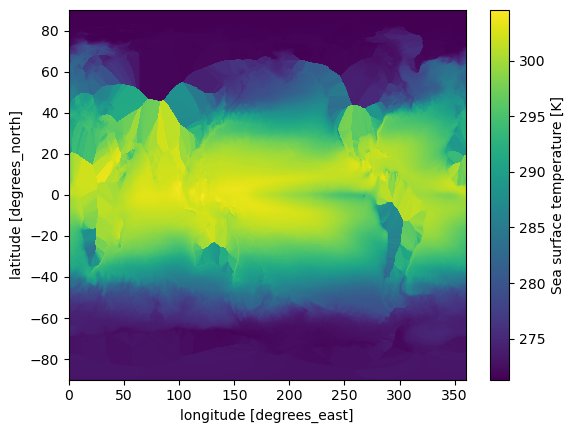

In [23]:
# # Load the regridded data
ds_final = xr.open_dataset(f"./{outputdir}/r025_cdo_{var}_mean_2000_to_2001.nc")
ds_final[var].plot()

In [24]:
# 1. Plot Test 01 from 2000-01-01 to 2001-12-31
ds_data = xr.open_dataset(f'{outputdir}/built_in_native_{var}_mean_{_startdate}_to_{_enddate}.nc')
ds_grid = xr.open_dataset("/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc")

# 2. Identify the horizontal dimension names
# Data usually has 'ncells', Grid usually has 'ncells' or 'nod2'
data_dim = list(ds_data.dims)[0] 
grid_dim = list(ds_grid.dims)[0]

print(f"Data dim: {data_dim}, Grid dim: {grid_dim}")

# 3. Rename the data dimension to match the grid exactly
ds_fixed = ds_data.rename({data_dim: grid_dim})

# 4. Attach coordinates from the MASTER grid to ensure alignment
ds_fixed['lat'] = ds_grid['lat']
ds_fixed['lon'] = ds_grid['lon']

# 5. Set attributes and WIPE encoding
ds_fixed.tos.attrs['coordinates'] = 'lat lon'
ds_fixed.tos.encoding = {}
ds_fixed.lat.encoding = {}
ds_fixed.lon.encoding = {}

# 6. Save as NetCDF3_CLASSIC (The most compatible format for CDO)
ds_fixed.to_netcdf(f"./{outputdir}/cdo_{var}_mean_2000_to_2001_builtin.nc", format="NETCDF3_CLASSIC")

# 7. Run CDO with the absolute path
! /sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/bin/cdo -f nc4 \
  remapdis,r1440x720 \
  -setgrid,/work/ab0995/a270260/AQUA_grids/FESOM/AQUA_NG5_griddes_nodes_IFS.nc \
  ./IFS_FESOM_tos_mean_native/cdo_tos_mean_2000_to_2001_builtin.nc \
  ./IFS_FESOM_tos_mean_native/r025_tos_mean_2000_to_2001_builtin.nc

Data dim: ncells, Grid dim: ncells
cdo(1) setgrid: Process started
Warning (cdfScanVarAttr): NetCDF: Variable not found - lon_bnds
Warning (cdfScanVarAttr): NetCDF: Variable not found - lat_bnds
cdo    remapdis: Distance-weighted average weights from unstructured (7402886) to lonlat (1440x720) grid
cdo(1) setgrid: Processed 7402886 values from 1 variable over 1 timestep.
cdo    remapdis: Processed 7402886 values from 1 variable over 1 timestep [5.29s 13GB].


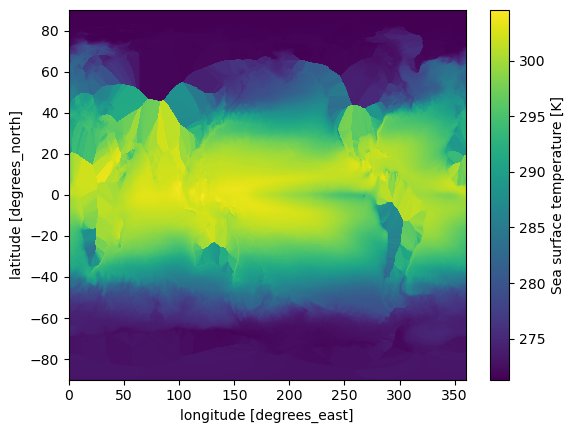

In [25]:
# # Load the regridded data
ds = xr.open_dataset(f"./{outputdir}/r025_tos_mean_2000_to_2001_builtin.nc")
ds[var].plot()

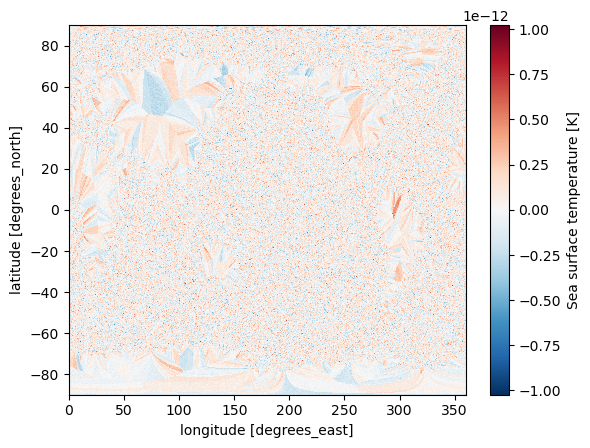

In [26]:
diff = ds_final - ds 
diff[var].plot()

In [27]:
###########################################################################################################

In [28]:
# import xarray as xr
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs

# # Load the regridded data
# ds_final = xr.open_dataset("eerie_STD_r025_2.nc")

# # Quick plot to verify
# plt.figure(figsize=(12, 6))
# ax = plt.axes(projection=ccrs.PlateCarree())
# ds_final.zos.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r')
# ax.coastlines()
# plt.title("Regridded Sea Surface Height (0.25°)")
# plt.show()

In [29]:
# ds_final = xr.open_dataset("eerie_STD_r025.nc")
# ds_final_2 = xr.open_dataset("eerie_STD_r025_2.nc")
# diff = ds_final - ds_final_2

In [30]:
# plot_dataset = {"catalog": "climatedt-phase1", "model": "IFS-FESOM", "exp":"historical-1950", } #"tgt_grid_name":tgt_grid_name}

# plot_class.plot(dataset_std=diff['zos'], **plot_dataset, vmin=0.0, vmax=0.6)